In [27]:
import pandas as pd
import numpy as np
import pandas_ta as ta
from pandas_ta.volatility import kc 
import enum

class EMA25(enum.Enum):
    PRICE_ACCION_NEUTRAL = 0
    PRICE_ACCION_UNDER = 1
    PRICE_ACCION_OVER = 2

def calculateBolingerAndKeltnerChannels(kc):
    # Bolinger Bands
    df.ta.bbands(append=True, length=20, std=2)
    
    # Initialize Keltner Channel Indictor
    kc=kc(high=df['High'], low=df['Low'], close=df["Close"], window=20)
    
    #Bolinger Band Upper - Keltner Channel Upper
    df['bbu_minus_kcu'] = df['BBU_20_2.0'] - kc['KCUe_20_2']
    
def detectPosibleBreak(window = 3):

    df['posibleBreak'] = EMA25['PRICE_ACCION_NEUTRAL'].value

    '''
    OVER PRICE ACCION
    '''
    cond = (df.squeezeCloseToEma == EMA25['PRICE_ACCION_UNDER'].value)
    cond2 = (len(cond.tail(3).values) == window)
    cond3 = (cond2 & (df.Close<df.ema25))
    cond4 = (cond3 & (df.squeezeCloseToEma)==EMA25['PRICE_ACCION_UNDER'].value)
    df.loc[cond4, 'posibleBreak'] = EMA25['PRICE_ACCION_UNDER'].value

    '''
    UNDER PRICE ACCION
    '''
    cond = (df.squeezeCloseToEma == EMA25['PRICE_ACCION_OVER'].value)
    cond2 = (len(cond.tail(3).values) == window)
    cond3 = (cond2 & (df.Close>df.ema25))
    cond4 = (cond3 & (df.squeezeCloseToEma==EMA25['PRICE_ACCION_OVER'].value))
    df.loc[cond4, 'posibleBreak'] = EMA25['PRICE_ACCION_OVER'].value

def detectSqueezeCloseToEMA(zoneWidth = .30):

    df['squeezeCloseToEma'] = EMA25['PRICE_ACCION_NEUTRAL'].value
    
    cond =((df.squeezedArea == EMA25['PRICE_ACCION_OVER'].value) & (abs(df.Low-df.ema25)<=zoneWidth))
    df.loc[cond, 'squeezeCloseToEma'] = EMA25['PRICE_ACCION_OVER'].value

    cond =((df.squeezedArea == EMA25['PRICE_ACCION_UNDER'].value) & (abs(df.High-df.ema25)<=zoneWidth))
    df.loc[cond, 'squeezeCloseToEma'] = EMA25['PRICE_ACCION_UNDER'].value
    
def detectSqueeze():
    
    df['squeezedArea'] = EMA25['PRICE_ACCION_NEUTRAL'].value
    cond = ((df.bbu_minus_kcu <= 0) & (df.Close < df.ema25))
    df.loc[cond, 'squeezedArea'] = EMA25['PRICE_ACCION_UNDER'].value
    
    cond2 =((df.bbu_minus_kcu <= 0) & (df.Close > df.ema25))
    df.loc[cond2, 'squeezedArea'] = EMA25['PRICE_ACCION_OVER'].value

if __name__ == '__main__':
    
    df = pd.read_csv("../data/MSFT/MSFT.USUSD_Candlestick_5_M_BID_01.09.2022-21.09.2024.csv")
    #df=df[0:10000]
    df=df[df['Volume']!=0]
    df.rename(columns = {'Gmt time':'datetime'}, inplace = True)
    df["datetime"]=df["datetime"].str.replace(".000","")
    df['datetime']=pd.to_datetime(df['datetime'],format='%d.%m.%Y %H:%M:%S')    
    df['ema25'] = df['Close'].ewm(span=25, adjust=False).mean()
    df=df[df.High!=df.Low]
    
    df.reset_index(drop=True, inplace=True)
    pd.options.mode.copy_on_write = True

    calculateBolingerAndKeltnerChannels(kc)
    detectSqueeze()
    detectSqueezeCloseToEMA()
    detectPosibleBreak()
    
    df = df[['datetime','Open','High','Low','Close','ema25','squeezedArea','squeezeCloseToEma','posibleBreak']]
    result = df.loc[df["squeezeCloseToEma"]==2]
result.tail(30)

,datetime,Open,High,Low,Close,ema25,squeezedArea,squeezeCloseToEma,posibleBreak
30553,2024-09-16 19:50:00,431.277,431.457,430.816,431.236,430.716930,2,2,2
30554,2024-09-16 19:55:00,431.236,431.596,430.937,431.356,430.766089,2,2,2
30584,2024-09-17 17:55:00,435.276,435.386,435.087,435.257,434.794173,2,2,2
30587,2024-09-17 19:10:00,434.737,435.177,434.726,435.106,434.803454,2,2,2
30588,2024-09-17 19:15:00,435.047,435.117,434.667,434.896,434.810573,2,2,2
30595,2024-09-17 19:50:00,434.737,435.027,434.516,434.797,434.708200,2,2,2
30616,2024-09-18 17:05:00,432.667,432.717,432.436,432.467,432.317598,2,2,2
30617,2024-09-18 17:10:00,432.436,432.637,432.346,432.426,432.325936,2,2,2
30618,2024-09-18 17:15:00,432.467,432.576,432.156,432.326,432.325941,2,2,2
30620,2024-09-18 17:25:00,432.016,432.627,432.016,432.517,432.315861,2,2,2


In [28]:
def posibleBreakArea(x):
    extraSpace = 1
    if (x['posibleBreak']==EMA25['PRICE_ACCION_OVER'].value):
        return x['Low']-extraSpace
    elif (x['posibleBreak']==EMA25['PRICE_ACCION_UNDER'].value):
        return x['High']+extraSpace    
    else:
        return np.nan
        
def squeezeCloseToEmaArea(x):
    extraSpace = .80
    if (x['squeezeCloseToEma']==EMA25['PRICE_ACCION_OVER'].value):
        return x['Low']-extraSpace
    elif (x['squeezeCloseToEma']==EMA25['PRICE_ACCION_UNDER'].value):
        return x['High']+extraSpace
    else:
        return np.nan
        
def squezzeArea(x):
    extraSpace = .50
    if (x['squeezedArea']==EMA25['PRICE_ACCION_OVER'].value):
        return x['Low']-extraSpace
    elif (x['squeezedArea']==EMA25['PRICE_ACCION_UNDER'].value):
        return x['High']+extraSpace
    else:
        return np.nan

df['squezzeArea'] = df.apply(lambda row: squezzeArea(row), axis=1)
df['squeezeCloseToEmaArea'] = df.apply(lambda row: squeezeCloseToEmaArea(row), axis=1)
df['posibleBreakArea'] = df.apply(lambda row: posibleBreakArea(row), axis=1)

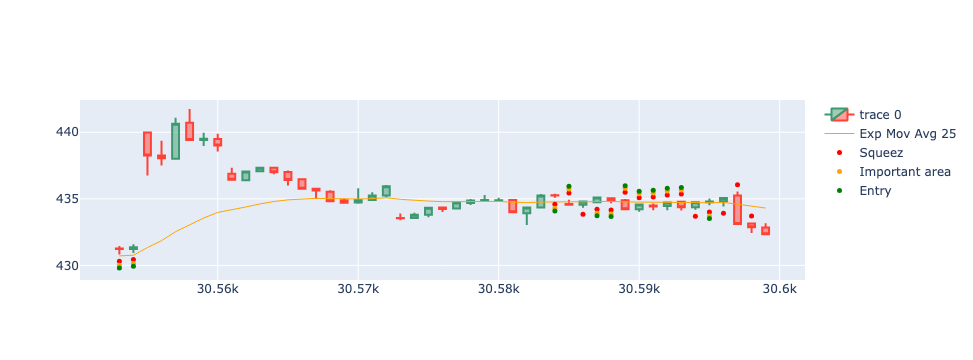

In [29]:
import plotly.io as pio
import plotly.graph_objects as go  

dfpl = df[30553:30600]

fig = go.Figure(
    data=[
        go.Candlestick(
            x=dfpl.index,
            open=dfpl['Open'],
            high=dfpl['High'],
            low=dfpl['Low'],
            close=dfpl['Close']),
        go.Scatter(
            x=dfpl.index, 
            y=dfpl['ema25'],
            line=dict(color='orange', width=1), 
            name="Exp Mov Avg 25")
    ]
)

fig.add_scatter(x=dfpl.index, y=dfpl['squezzeArea'], mode="markers", marker=dict(size=5, color="red"), name="Squeez")
fig.add_scatter(x=dfpl.index, y=dfpl['squeezeCloseToEmaArea'], mode="markers", marker=dict(size=5, color="orange"), name="Important area")
fig.add_scatter(x=dfpl.index, y=dfpl['posibleBreakArea'], mode="markers", marker=dict(size=5, color="green"), name="Entry")

fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()
